# SciGRID Network

In this example, the dispatch of generators is optimized using the linear optimization, then a non-linear power flow is run on the resultign dispatch. This example covers the German power system (roughly in the mid 2010s) for a single day at hourly resolution.

#### Data Sources
* **Grid:** Based on [SciGRID](https://openenergyplatform.org/factsheets/models/22/) which is based on [OpenStreetMap](http://openstreetmap.org/#map=4/38.01/-95.84).
* **Load size and location:** Distributed proportional to NUTS3 and population. In doubt, load and generation is attached to the 220kV substation.
* **Load time series:** From ENTSO-E hourly data, scaled up uniformly by factor 1.12 (a simplification of the methodology in [Schumacher and Hirth (2025)](https://ideas.repec.org/p/fem/femwpa/2015.88.html))
* **Conventional power plant capacities and locations:** Based on list of [BNetzA](https://www.bundesnetzagentur.de/DE/Home/home_node.html) (German Federal Network Agency).
* **Wind and solar capacities and locations:** Based on [EEG Stammdaten](https://www.netztransparenz.de/de-de/Erneuerbare-Energien-und-Umlagen/EEG/EEG-Abrechnungen/EEG-Jahresabrechnungen/EEG-Anlagenstammdaten), [Energy Map](http://www.energymap.info/download.html), which represents capacities at the end of 2014.
* **Wind and solar time series:** Generated with REatlas tool based on [Andersen et al. (2015)](https://www.sciencedirect.com/science/article/pii/S0360544215012815?via%3Dihub)

#### Warnings

**The data behind this example is no longer supported or updated. The dataset is only intended to demonstrate the capabilities of PyPSA and is not suitable for research purposes. Have a look at PyPSA-Eur for a newer grid model with active support.**

Known problems include:
1. Rough approximations have been made for missing grid data, e.g. 220kV-380kV transformers and connections between close sub-stations missing from OSM.
2. There appears to be some unexpected congestion in parts of the network, which may mean for example that the load attachment method is inaccurate, particularly in regions with a high density of substations.
3. Attaching power plants to the nearest high voltage substation may not reflect reality.
4. The borders and neighbouring countries are not represented.
5. Hydroelectric power stations are not modelled accurately.
6. The marginal costs of generators are illustrative, not accurate.
7. Only the first day of 2011 is in the example, which is not resentative.
8. The ENTSO-E total load for Germany may not be scaled correctly.
9. Biomass from the EEG reference data (Stammdaten) are not read in.
10. Power plant start up costs, ramping limits, and minimum part loads are not considered.

### Input Data

In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pypsa

n = pypsa.examples.scigrid_de()

INFO:pypsa.network.io:Retrieving network data from https://github.com/PyPSA/PyPSA/raw/v1.0.7/examples/networks/scigrid-de/scigrid-de.nc.
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'SciGrid-DE' has buses, carriers, generators, lines, loads, storage_units, transformers


Plot the distribution of the load and of generating tech

/usr/local/python/3.12.1/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip

/usr/local/python/3.12.1/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning:

Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip



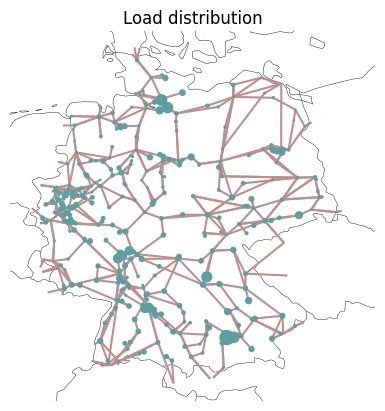

In [2]:
fig, ax = plt.subplots(
    1, 1,
    subplot_kw = {"projection": ccrs.EqualEarth()},
)

load_distribution = n.loads_t.p_set.loc[n.snapshots[0]].groupby(n.loads.bus).sum()
n.plot(bus_size = load_distribution / 30000, ax = ax, title = "Load distribution");

In [3]:
n.generators.groupby("carrier")["p_nom"].sum().round(1)

carrier
Brown Coal       20879.5
Gas              23913.1
Geothermal          31.7
Hard Coal        25312.6
Multiple           152.7
Nuclear          12068.0
Oil               2710.2
Other             3027.8
Run of River      3999.1
Solar            37041.5
Storage Hydro     1445.0
Waste             1645.9
Wind Offshore     2973.5
Wind Onshore     37339.9
Name: p_nom, dtype: float64

In [4]:
n.storage_units.groupby("carrier")["p_nom"].sum().round(1)

carrier
Pumped Hydro    9179.5
Name: p_nom, dtype: float64

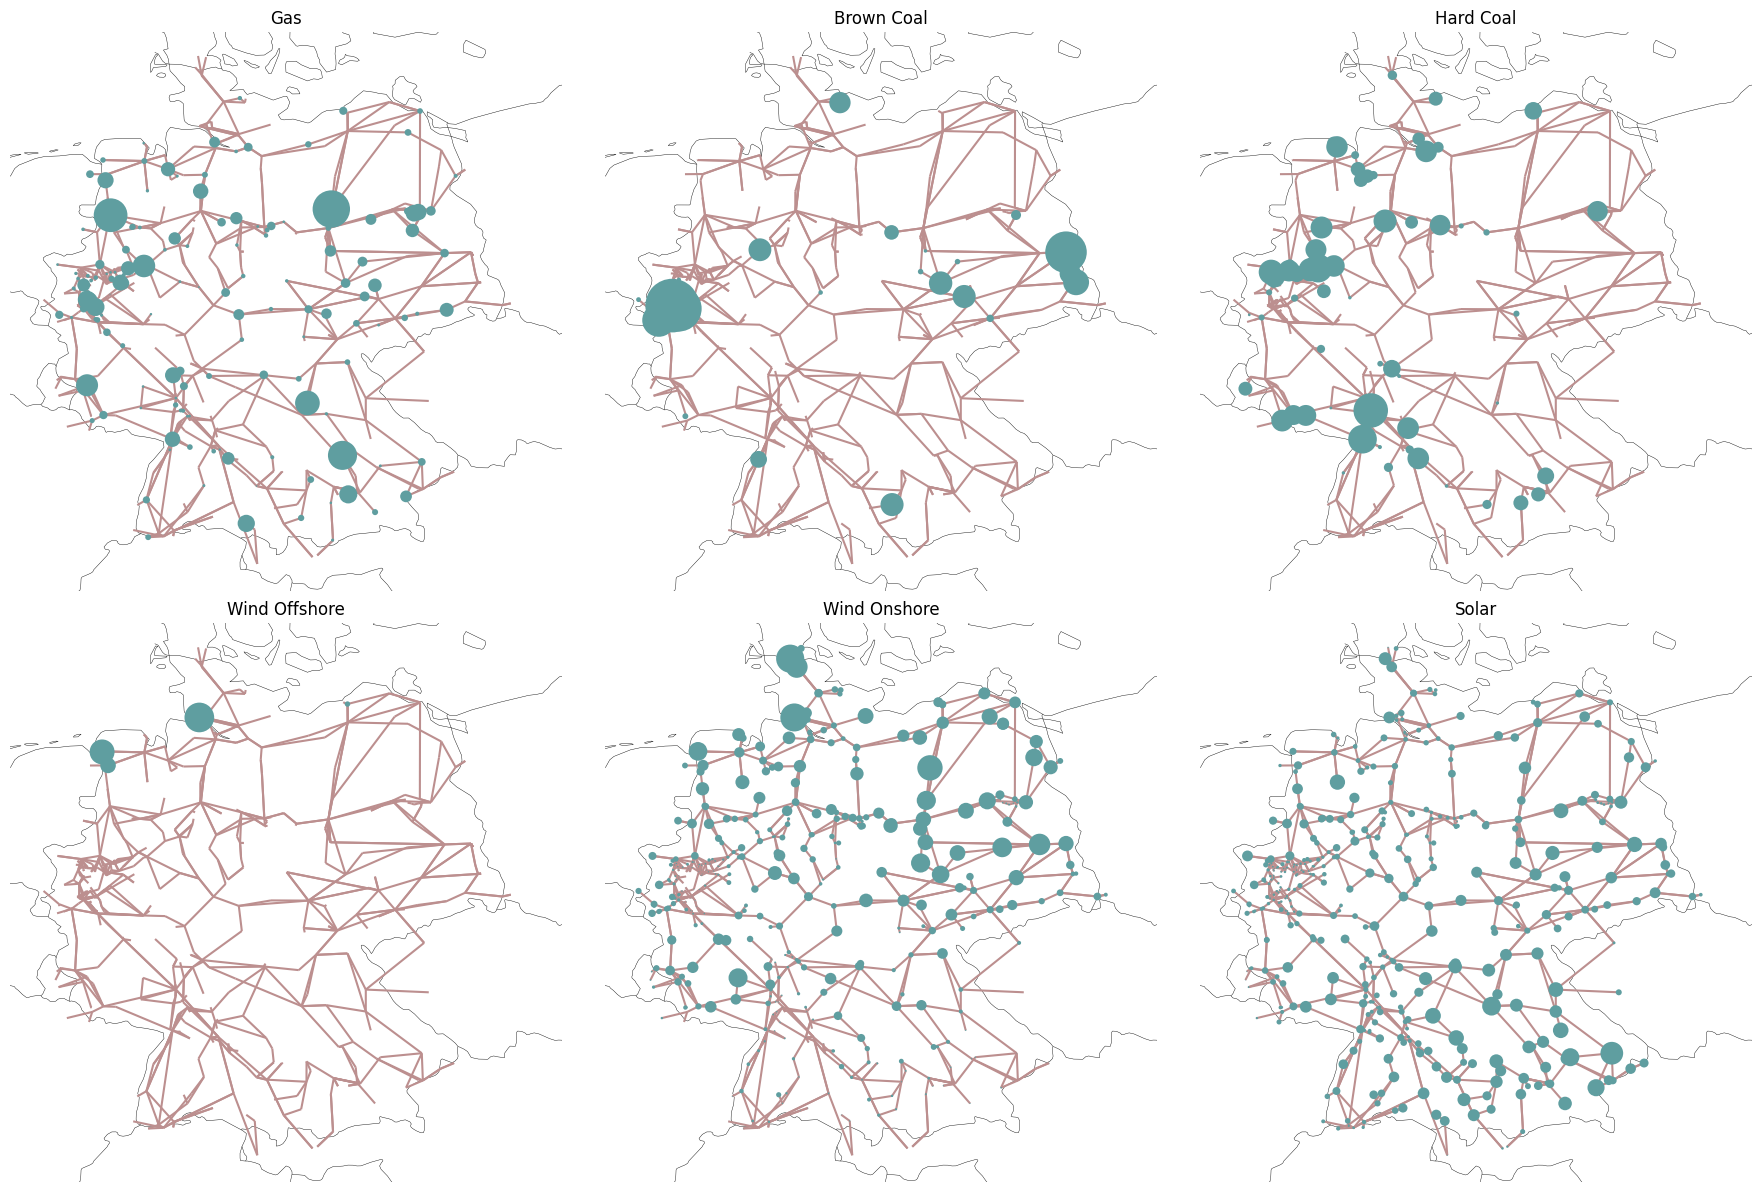

In [5]:
techs = ["Gas", "Brown Coal", "Hard Coal", "Wind Offshore", "Wind Onshore", "Solar"]
n_graphs = len(techs)
n_cols = 3
if n_graphs % n_cols == 0:
    n_rows = n_graphs // n_cols
else:
    n_rows = n_graphs // n_cols + 1

fig, axes = plt.subplots(
    n_rows, n_cols,
    subplot_kw = {"projection": ccrs.EqualEarth()})
size = 6
fig.set_size_inches(size * n_cols, size * n_rows)

for i, tech in enumerate(techs):
    i_row = i // n_cols
    i_col = i % n_cols

    ax = axes[i_row, i_col]
    gens = n.generators[n.generators.carrier == tech]
    gen_distribution = gens.groupby("bus").sum()["p_nom"].reindex(n.buses.index, fill_value = 0)
    n.plot(ax=ax, bus_size = gen_distribution / 20000)
    ax.set_title(tech)
fig.tight_layout()

### Rolling Horizon Optimization

Run optimization (linear optimal power flow) on the first day of 2011.

To approximate $N-1$ security and allow room for reactive power flows, we do not allow any line to be loaded above 70% of their thermal rating:

In [6]:
contingency_factor = 0.7
n.lines.s_max_pu = contingency_factor

There are some infeasibilities without small extensions

In [7]:
n.lines.loc[["316", "527", "602"], "s_nom"] = 1715

We are performing the optimization for one day, 4 snapshots at a time.

In [8]:
n.optimize.optimize_with_rolling_horizon(horizon=4, overlap=0)

INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2011-01-01 00:00:00:2011-01-01 03:00:00] (1/6).
Index(['2', '5', '10', '12', '13', '15', '18', '20', '22', '24', '26', '30',
       '32', '37', '42', '46', '52', '56', '61', '68', '69', '74', '78', '86',
       '87', '94', '95', '96', '99', '100', '104', '105', '106', '107', '117',
       '120', '123', '124', '125', '128', '129', '138', '143', '156', '157',
       '159', '160', '165', '184', '191', '195', '201', '220', '231', '232',
       '233', '236', '247', '248', '250', '251', '252', '261', '263', '264',
       '267', '272', '279', '281', '282', '292', '303', '307', '308', '312',
       '315', '317', '322', '332', '334', '336', '338', '351', '353', '360',
       '362', '382', '384', '385', '391', '403', '404', '413', '421', '450',
       '458'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 3.61s


Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-coz8q75z has 23828 rows; 9940 cols; 43906 nonzeros
Coefficient ranges:
  Matrix  [1e-02, 2e+02]
  Cost    [3e+00, 1e+02]
  Bound   [0e+00, 0e+00]
  RHS     [7e-08, 6e+03]
Presolving model
3039 rows, 6674 cols, 18332 nonzeros  0s
2307 rows, 5926 cols, 17304 nonzeros  0s
Dependent equations search running on 2078 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
2078 rows, 5102 cols, 16392 nonzeros  0s
Presolve reductions: rows 2078(-21750); columns 5102(-4838); nonzeros 16392(-27514) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 9940 primals, 23828 duals
Objective: 1.45e+06
Solver model: available
Solver message: Optimal



       2769     1.4496872501e+06 Pr: 0(0); Du: 0(4.79616e-14) 0s
       2769     1.4496872501e+06 Pr: 0(0); Du: 0(4.79616e-14) 0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-coz8q75z
Model status        : Optimal
Simplex   iterations: 2769
Objective value     :  1.4496872501e+06
P-D objective error :  4.3364009788e-15
HiGHS run time      :          0.33


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Transformer-fix-s-lower, Transformer-fix-s-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.
INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2011-01-01 04:00:00:2011-01-01 07:00:00] (2/6).
Index(['2', '5', '10', '12', '13', '15', '18', '20', '22', '24', '26', '30',
       '32', '37', '42', '46', '52', '56', '61', '68', '69', '74', '78', '86',
       '87', '94', '95', '96', '99', '100', '104', '105', '106', '107', '117',
       '120', '123', '124', '125', '128', '129', '138', '143', '156', '157',
       '159', '160', '165', '184', '191', '195', '201', '220', '231', '2

...

INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2011-01-01 20:00:00:2011-01-01 23:00:00] (6/6).
Index(['2', '5', '10', '12', '13', '15', '18', '20', '22', '24', '26', '30',
       '32', '37', '42', '46', '52', '56', '61', '68', '69', '74', '78', '86',
       '87', '94', '95', '96', '99', '100', '104', '105', '106', '107', '117',
       '120', '123', '124', '125', '128', '129', '138', '143', '156', '157',
       '159', '160', '165', '184', '191', '195', '201', '220', '231', '232',
       '233', '236', '247', '248', '250', '251', '252', '261', '263', '264',
       '267', '272', '279', '281', '282', '292', '303', '307', '308', '312',
       '315', '317', '322', '332', '334', '336', '338', '351', '353', '360',
       '362', '382', '384', '385', '391', '403', '404', '413', '421', '450',
       '458'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.2s


Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
LP linopy-problem-uk5ib8w4 has 23828 rows; 9940 cols; 43906 nonzeros
Coefficient ranges:
  Matrix  [1e-02, 2e+02]
  Cost    [3e+00, 1e+02]
  Bound   [0e+00, 0e+00]
  RHS     [9e-11, 6e+03]
Presolving model
3085 rows, 6973 cols, 18738 nonzeros  0s
2156 rows, 6006 cols, 17588 nonzeros  0s
Dependent equations search running on 2085 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
2085 rows, 5260 cols, 16738 nonzeros  0s
Presolve reductions: rows 2085(-21743); columns 5260(-4680); nonzeros 16738(-27168) 
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 9940 primals, 23828 duals
Objective: 2.14e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Transformer-fix-s-lower, Transformer-fix-s-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


       2764     2.1429568887e+06 Pr: 0(0); Du: 0(6.21725e-15) 0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-uk5ib8w4
Model status        : Optimal
Simplex   iterations: 2764
Objective value     :  2.1429568887e+06
P-D objective error :  1.4124398289e-15
HiGHS run time      :          0.35


PyPSA Network 'SciGrid-DE'
--------------------------
Components:
 - Bus: 585
 - Carrier: 16
 - Generator: 1423
 - Line: 852
 - Load: 489
 - StorageUnit: 38
 - SubNetwork: 1
 - Transformer: 96
Snapshots: 24

### Plot dispatch time series

In [10]:
p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
to_drop = p_by_carrier.max()[p_by_carrier.max() < 1700].index
p_by_carrier.drop(columns = to_drop, axis=1, inplace = True)
p_by_carrier.columns

Index(['Brown Coal', 'Gas', 'Hard Coal', 'Nuclear', 'Run of River', 'Solar',
       'Wind Offshore', 'Wind Onshore'],
      dtype='object', name='carrier')

In [12]:
colors = {
    "Gas": "orange",
    "Brown Coal": "brown",
    "Hard Coal": "k",
    "Wind Offshore": "cyan",
    "Wind Onshore": "blue",
    "Solar": "yellow",
    "Nuclear": "r",
    "Run of River": "green",
    "Waste": "orange",
}

# reorder
cols = ["Nuclear",
        "Run of River",
        "Brown Coal",
        "Hard Coal",
        "Gas",
        "Wind Offshore",
        "Wind Onshore",
        "Solar",]
p_by_carrier = p_by_carrier[cols]